# Feature Selection and Model Creation

# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import RFE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Import Clean Dataset

In [2]:
dataset = pd.read_csv("Clean_Amazon_Dataset.csv")

print(dataset.shape)

dataset.head()

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,wayona nylon braided usb to lightning fast cha...,computers&accessories|accessories&peripherals|...,399.0,1099.0,64,4.2,24269.0,high compatibility compatible with iphone 12 ...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...",satisfiedcharging is really fastvalue for mone...,looks durable charging is fine toono complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,ambrane unbreakable 60w 3a fast charging 15m ...,computers&accessories|accessories&peripherals|...,199.0,349.0,43,4.0,43994.0,compatible with all type c enabled devices be ...,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...",a good braided cable for your type c devicegoo...,i ordered this cable to connect my phone to an...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,sounce fast phone charging cable data sync us...,computers&accessories|accessories&peripherals|...,199.0,1899.0,90,3.9,7928.0,fast charger data syncwith builtin safety pro...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...",good speed for earlier versionsgood productwor...,not quite durable and sturdyhttpsmmediaamazonc...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boat deuce usb 300 2 in 1 typec micro usb str...,computers&accessories|accessories&peripherals|...,329.0,699.0,53,4.2,94363.0,the boat deuce usb 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...",good productgood onenicereally nice productver...,good productlong wirecharges goodnicei bought ...,https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,portronics konnect l 12m fast charging 3a 8 pi...,computers&accessories|accessories&peripherals|...,154.0,399.0,61,4.2,16905.0,charge sync function this cable comes with ch...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...",as good as originaldecentgood one for secondar...,bought this instead of original apple does the...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


# DATA ASSESSMENT

In [3]:
# Display the data types and non-null information for every column

dataset.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [4]:
# Checks the number of missing values in each column.

dataset.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [5]:
# Checks whether duplicate records exist.

dataset.duplicated().sum()

np.int64(0)

# Create Opportunity Score - Introduce business-rule based Opportunity Score

The Opportunity Score combines below features into one numerical score to provide single measure that represents the attractiveness of a product from Seller's perspective: 
1. Rating
2. Rating Count
3. Discount Percentage
4. Discount Price

In [6]:
# 1. Convert the customer rating from a 0–5 scale into a 0–100 score. 
# 2. Higher customer ratings produce higher rating scores, indicating better customer satisfaction.

dataset["rating_score"] = (dataset["rating"] / 5) * 100

In [7]:
dataset["rating_score"] 

0       84.0
1       80.0
2       78.0
3       84.0
4       84.0
        ... 
1460    80.0
1461    82.0
1462    72.0
1463    80.0
1464    86.0
Name: rating_score, Length: 1465, dtype: float64

In [8]:
# 1. Creates a normalized demand score using rating_count.
# 2. The product with the highest rating count receives a demand score of 100. Other products receive a proportional score.

dataset["demand_score"] = (dataset["rating_count"] / dataset["rating_count"].max()) * 100

In [9]:
dataset["demand_score"] 

0        5.683966
1       10.303696
2        1.856792
3       22.100461
4        3.959267
          ...    
1460     0.255285
1461     0.964464
1462     0.109609
1463     1.880915
1464     1.636403
Name: demand_score, Length: 1465, dtype: float64

In [10]:
# 1. Use the existing discount percentage directly as the discount score
# 2. Higher discount percentages contribute positively to the Opportunity Score

dataset["discount_score"] = (dataset["discount_percentage"])

In [11]:
dataset["discount_score"]

0       64
1       43
2       90
3       53
4       61
        ..
1460    59
1461    25
1462    28
1463    26
1464    22
Name: discount_score, Length: 1465, dtype: int64

In [12]:
# 1. Creates a price suitability score
# 2. Lower-priced products are considered more suitable for a new seller because the seller can potentially purchase more units while requiring
# less capital per product.

dataset["price_score"] = (1 - dataset["discounted_price"] / dataset["discounted_price"].max()) * 100

In [13]:
dataset["price_score"] 

0       99.488396
1       99.744839
2       99.744839
3       99.578151
4       99.802539
          ...    
1460    99.514040
1461    97.076548
1462    97.154763
1463    98.206180
1464    96.329017
Name: price_score, Length: 1465, dtype: float64

# Calculate Opportunity Score

In [14]:
dataset["Opportunity_Score"] = (
    0.30 * dataset["rating_score"] +
    0.30 * dataset["demand_score"] +
    0.20 * dataset["discount_score"] +
    0.20 * dataset["price_score"]
)

In [15]:
dataset[
        [
            "product_name",
            "rating",
            "rating_count",
            "discount_percentage",
            "discounted_price",
            "Opportunity_Score"
        ]
    ].head(20)

,product_name,rating,rating_count,discount_percentage,discounted_price,Opportunity_Score
0,wayona nylon braided usb to lightning fast cha...,4.2,24269.0,64,399.00,59.602869
1,ambrane unbreakable 60w 3a fast charging 15m ...,4.0,43994.0,43,199.00,55.640077
2,sounce fast phone charging cable data sync us...,3.9,7928.0,90,199.00,61.906005
3,boat deuce usb 300 2 in 1 typec micro usb str...,4.2,94363.0,53,329.00,62.345768
4,portronics konnect l 12m fast charging 3a 8 pi...,4.2,16905.0,61,154.00,58.548288
5,ptron solero tb301 3a typec data and fast char...,3.9,24871.0,85,149.00,62.109278
6,boat micro usb 55 tanglefree sturdy micro usb ...,4.1,15188.0,65,176.63,58.621845
7,mi usb typec cable smartphone black,4.3,30411.0,23,229.00,52.478014
8,tplink usb wifi adapter for pctlwn725n n150 wi...,4.2,179691.0,50,499.00,67.697494
9,ambrane unbreakable 60w 3a fast charging 15m ...,4.0,43994.0,33,199.00,53.640077


# Create Opportunity Label

In [16]:
# Defining business rule 

def opportunity_label(score):
    if score >= 60:
        return "BUY"

    elif score >= 50:
        return "CONSIDER"

    else:
        return "DON'T BUY"

In [17]:
dataset.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'rating_score',
       'demand_score', 'discount_score', 'price_score', 'Opportunity_Score'],
      dtype='object')

In [18]:
# Apply the previously defined function to every product - This becomes the target variable for supervised classification.

dataset["Opportunity_Label"] = (dataset["Opportunity_Score"].apply(opportunity_label))

In [19]:
dataset["Opportunity_Label"]

0        CONSIDER
1        CONSIDER
2             BUY
3             BUY
4        CONSIDER
          ...    
1460     CONSIDER
1461    DON'T BUY
1462    DON'T BUY
1463    DON'T BUY
1464    DON'T BUY
Name: Opportunity_Label, Length: 1465, dtype: object

In [20]:
# Count the number of products in each target category

dataset["Opportunity_Label"].value_counts()

Opportunity_Label
CONSIDER     905
DON'T BUY    324
BUY          236
Name: count, dtype: int64

In [21]:
# Display percentage distribution

label_percentage = (
    dataset["Opportunity_Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentage)

Opportunity_Label
CONSIDER     61.77
DON'T BUY    22.12
BUY          16.11
Name: proportion, dtype: float64


# TARGET DISTRIBUTION VISUALIZATION 
Create bar chart showing number of products in each Opportunity Label

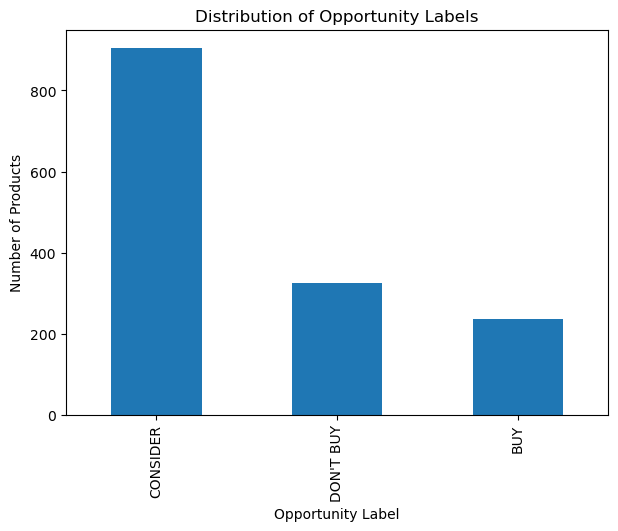

In [22]:
plt.figure(figsize=(7,5))

dataset["Opportunity_Label"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Opportunity Label")
plt.ylabel("Number of Products")

plt.title(
    "Distribution of Opportunity Labels"
)

plt.show()

# Taller bar indicate that the "CONSIDER" category contains more products

In [23]:
#INFERENCE: The target distribution is highly imbalanced, with CONSIDER as the dominant class and BUY as the minority class. Hence, BUY Recall and F1-score are important evaluation metrics to ensure that potential stocking opportunities are not missed.

# Check Opportunity Score Distribution 
Displays the distribution of Opportunity Scores across products

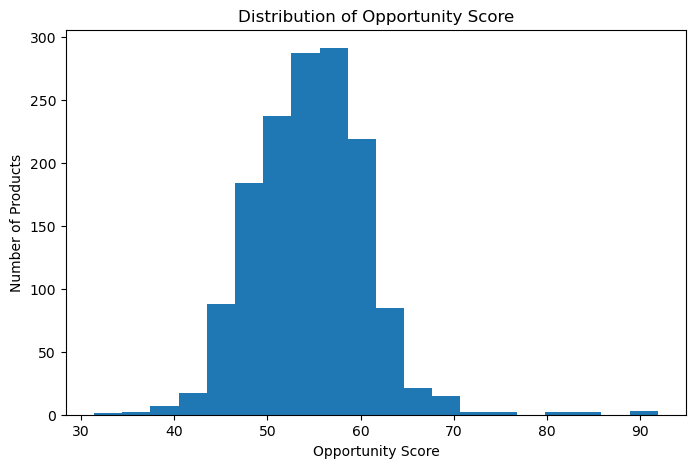

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    dataset["Opportunity_Score"],
    bins=20
)

plt.xlabel("Opportunity Score")
plt.ylabel("Number of Products")

plt.title(
    "Distribution of Opportunity Score"
)

plt.show()

In [25]:
# INFERENCE: The Opportunity Score is mainly concentrated between 45 and 65, indicating that most products have moderate stocking potential. A smaller number of products achieve scores above 60, representing stronger opportunities for the seller to consider for stocking.

# Prepare Features and Target

In [26]:
features = [
    "discounted_price",
   # "actual_price",
    "discount_percentage",
    "rating",
    "rating_count"
]

X = dataset[features]

y = dataset["Opportunity_Label"]

In [27]:
print("Features:", X.columns)

Features: Index(['discounted_price', 'discount_percentage', 'rating', 'rating_count'], dtype='object')


In [28]:
y

0        CONSIDER
1        CONSIDER
2             BUY
3             BUY
4        CONSIDER
          ...    
1460     CONSIDER
1461    DON'T BUY
1462    DON'T BUY
1463    DON'T BUY
1464    DON'T BUY
Name: Opportunity_Label, Length: 1465, dtype: object

In [29]:
print("Target:", y.name)

Target: Opportunity_Label


# Correlation Analysis (untrained features)

In [30]:
X.corr()

,discounted_price,discount_percentage,rating,rating_count
discounted_price,1.000000,-0.242412,0.120335,-0.027081
discount_percentage,-0.242412,1.000000,-0.155273,0.011097
rating,0.120335,-0.155273,1.000000,0.101526
rating_count,-0.027081,0.011097,0.101526,1.000000


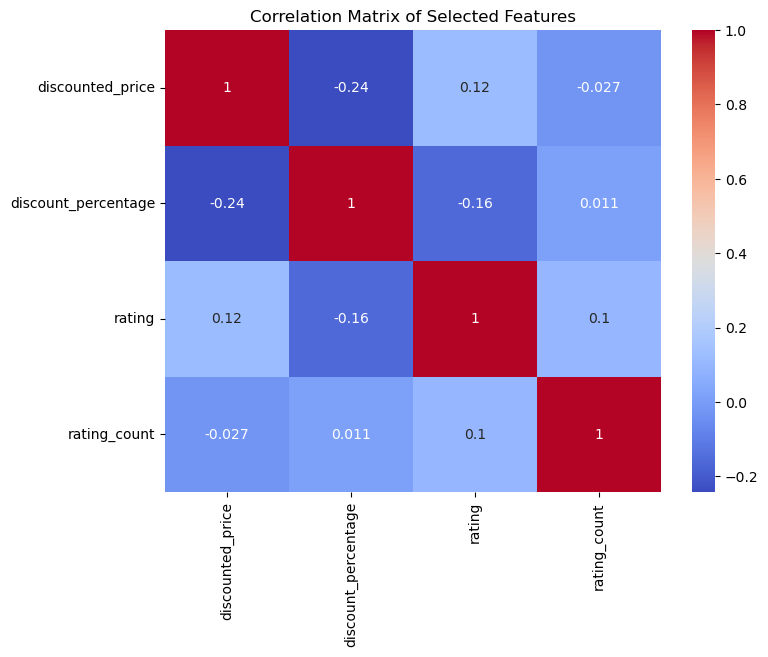

In [31]:
plt.figure(figsize=(8,6))
correlation_matrix = X.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix of Selected Features"
)

plt.show()

# Train/Test Split

1. Splits the data into:
	• 80% training data 
	• 20% testing data 
2. stratify=y ensures that the class proportions are approximately maintained in both training and testing datasets.
3. The model is trained using the training data and evaluated on previously unseen test data.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=0,

    stratify=y
)

# Feature Selection Using SelectKBest 
To identify which individual features have the strongest statistical relationship with the target

In [33]:
selector = SelectKBest(
    score_func=chi2,
    k="all"
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

feature_scores = pd.DataFrame({

    "Feature": X_train.columns,

    "Score": selector.scores_,

    "P_Value": selector.pvalues_

})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores

,Feature,Score,P_Value
3,rating_count,2.247893e+07,0.000000
0,discounted_price,3.051641e+06,0.000000
1,discount_percentage,6.442015e+03,0.000000
2,rating,7.739942e-01,0.679093


In [34]:
#INFERENCE: SelectKBest shows that rating_count, discounted_price and discount_percentage have statistically significant associations with the Opportunity Label (p < 0.05), with rating_count having the highest Chi-Square score. Rating has a p-value of 0.679 and therefore does not show a statistically significant association in this test. However, rating is retained as it has direct business relevance and can be evaluated further during model development.

# RFE Feature Selection 
To identify which combination of features works best with this particular model

In [35]:
rfe_estimator = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=0
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=2
)

rfe.fit(
    X_train,
    y_train
)


rfe_results = pd.DataFrame({

    "Feature": X_train.columns,

    "Selected": rfe.support_,

    "Ranking": rfe.ranking_

})
rfe_results

C:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Selected,Ranking
0,discounted_price,False,2
1,discount_percentage,True,1
2,rating,True,1
3,rating_count,False,3


In [36]:
# INFERENCE: RFE selected discount_percentage and rating as the top two features for the Logistic Regression-based feature selection. However, a convergence warning was observed because the input features have different scales. Therefore, the RFE result should be validated after appropriate feature scaling before using it for final feature selection.

# Correlation among final features

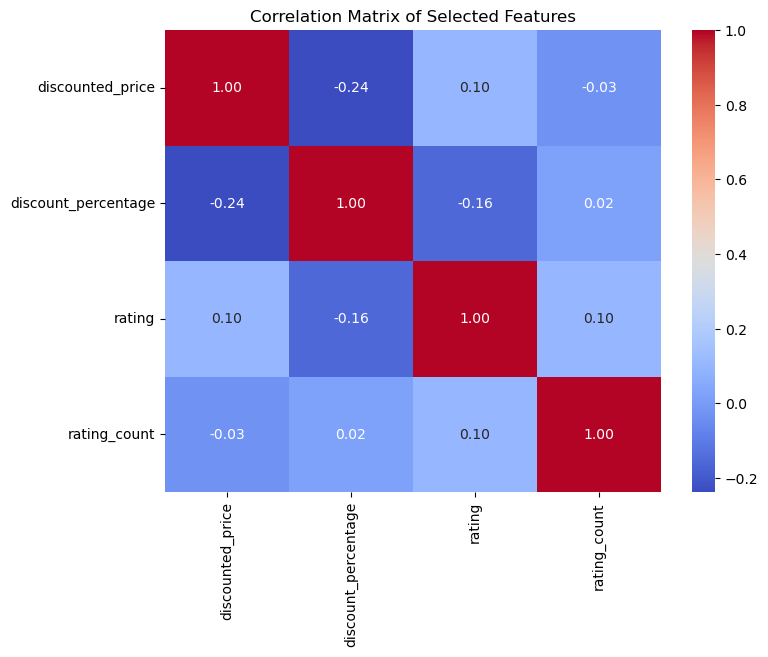

In [37]:
correlation = X_train.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Selected Features"
)

plt.show()

In [38]:
# INFERENCE: The final features show weak or negligible correlations with each other, with the strongest correlation being -0.24 between discounted price and discount percentage. This indicates low multicollinearity and suggests that the selected features provide relatively independent information to the classification model.

# GridSearchCV
1. Introduces hyperparameter tuning using GridSearchCV
2. Instead of manually selecting model parameters, GridSearchCV systematically tests multiple combinations and identifies the best-performing combination

# Logistic Regression GridSearch

In [39]:
from sklearn.pipeline import Pipeline

# Pipeline performs the below sequence internally, no explicit calls:
# X_scaled = scaler.fit_transform(X_train)
# classifier.fit(X_scaled, y_train)

logistic_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),  # within this code X_train is being fit & transformed inside the Pipeline
    
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=0,
        class_weight="balanced"
    ))
])

logistic_parameters = {
    
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    
    "classifier__solver": [
        "lbfgs",
        "liblinear"
    ]
}

grid_logistic = GridSearchCV(
    estimator=logistic_pipeline, # scaled X_train from pipeline is passed to logistic regression model
    param_grid=logistic_parameters,
    scoring="f1_macro", # since the target is imbalanced, F1 Macro gives equal importance to each class rather than allowing the majority class to dominate the evaluation.
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_logistic.fit(X_train, y_train) #scaled X_train from pipeline is fit into logistic regression model


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [40]:
# See Scaled values

grid_logistic.best_estimator_.named_steps["scaler"].transform(X_train)[:5]

array([[-0.36212543,  1.0255966 ,  0.35233552, -0.42167765],
       [-0.40343929,  1.0255966 ,  0.35233552, -0.18435926],
       [-0.37720348,  1.20945881,  0.00964902, -0.41345074],
       [-0.39982056,  0.38207886, -1.70378347, -0.41545675],
       [-0.34704738, -0.26143889, -0.33303748, -0.09807806]])

In [41]:
grid_logistic.best_params_

{'classifier__C': 100, 'classifier__solver': 'liblinear'}

In [42]:
grid_logistic.best_score_

np.float64(0.9877206046961853)

# SVM Linear GridSearch

In [43]:
from sklearn.svm import SVC

svm_linear_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),
    
    ("classifier", SVC(
        kernel="linear",
        random_state=0,
        class_weight="balanced"
    ))
])

svm_linear_parameters = {
    
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid_svm_linear = GridSearchCV(
    estimator=svm_linear_pipeline,
    param_grid=svm_linear_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svm_linear.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [44]:
# See Scaled values

grid_svm_linear.best_estimator_.named_steps["scaler"].transform(X_train)[:5]

array([[-0.36212543,  1.0255966 ,  0.35233552, -0.42167765],
       [-0.40343929,  1.0255966 ,  0.35233552, -0.18435926],
       [-0.37720348,  1.20945881,  0.00964902, -0.41345074],
       [-0.39982056,  0.38207886, -1.70378347, -0.41545675],
       [-0.34704738, -0.26143889, -0.33303748, -0.09807806]])

In [45]:
grid_svm_linear.best_params_

{'classifier__C': 100}

In [46]:
grid_svm_linear.best_score_

np.float64(0.9912987821759405)

# SVM RBF GridSearch

In [47]:
svm_rbf_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),
    
    ("classifier", SVC(
        kernel="rbf",
        random_state=0,
        class_weight="balanced"
    ))
])

svm_rbf_parameters = {
    
    "classifier__C": [
        0.1,
        1,
        10,
        100
    ],
    
    "classifier__gamma": [
        "scale",
        0.001,
        0.01,
        0.1,
        1
    ]
}

grid_svm_rbf = GridSearchCV(
    estimator=svm_rbf_pipeline,
    param_grid=svm_rbf_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svm_rbf.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'classifier__C': [0.1, 1, ...], 'classifier__gamma': ['scale', 0.001, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [48]:
# See Scaled values

grid_svm_rbf.best_estimator_.named_steps["scaler"].transform(X_train)[:5]

array([[-0.36212543,  1.0255966 ,  0.35233552, -0.42167765],
       [-0.40343929,  1.0255966 ,  0.35233552, -0.18435926],
       [-0.37720348,  1.20945881,  0.00964902, -0.41345074],
       [-0.39982056,  0.38207886, -1.70378347, -0.41545675],
       [-0.34704738, -0.26143889, -0.33303748, -0.09807806]])

In [49]:
grid_svm_rbf.best_params_

{'classifier__C': 100, 'classifier__gamma': 0.1}

In [50]:
grid_svm_rbf.best_score_

np.float64(0.978140495953349)

# KNN GridSearch

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    
    ("scaler", StandardScaler()),
    
    ("classifier", KNeighborsClassifier())
])

knn_parameters = {
    
    "classifier__n_neighbors": [
        3,
        5,
        7,
        9,
        11
    ],
    
    "classifier__weights": [
        "uniform",
        "distance"
    ],
    
    "classifier__metric": [
        "euclidean",
        "manhattan",
        "minkowski"
    ]
}

grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__metric': ['euclidean', 'manhattan', ...], 'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [52]:
grid_knn.best_params_

{'classifier__metric': 'euclidean',
 'classifier__n_neighbors': 3,
 'classifier__weights': 'distance'}

In [53]:
grid_knn.best_score_

np.float64(0.9580494681615199)

# Naive Bayes GridSearch

In [54]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()

nb_parameters = {
    
    "var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}

grid_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(
    X_train,
    y_train
)



Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [1e-11, 1e-10, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [55]:
grid_nb.best_params_

{'var_smoothing': 1e-10}

In [56]:
grid_nb.best_score_

np.float64(0.7538350946511907)

# Decision Tree GridSearch

In [57]:
from sklearn.tree import DecisionTreeClassifier

decision_model = DecisionTreeClassifier(
    random_state=0,
    class_weight="balanced"
)

decision_parameters = {
    
    "criterion": [
        "gini",
        "entropy"
    ],
    
    "max_depth": [
        None,
        3,
        5,
        7,
        10
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],
    
    "min_samples_leaf": [
        1,
        2,
        4
    ]
}    

grid_decision = GridSearchCV(
    estimator=decision_model,
    param_grid=decision_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_decision.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,estimator,DecisionTreeC...andom_state=0)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [58]:
grid_decision.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [59]:
grid_decision.best_score_

np.float64(0.9294305975400714)

# Random Forest GridSearch

In [60]:
from sklearn.ensemble import RandomForestClassifier

random_model = RandomForestClassifier(
    random_state=0,
    class_weight="balanced"
)

random_parameters = {
    
    "n_estimators": [
        50,
        100,
        200
    ],
    
    "criterion": [
        "gini",
        "entropy"
    ],
    
    "max_depth": [
        None,
        5,
        10,
        15
    ],
    
    "min_samples_split": [
        2,
        5,
        10
    ],
    
    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

grid_random = GridSearchCV(
    estimator=random_model,
    param_grid=random_parameters,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_random.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [61]:
grid_random.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 50}

In [62]:
grid_random.best_score_

np.float64(0.9473823295574689)

# COMPARE GRIDSEARCH RESULTS

In [63]:
grid_results = pd.DataFrame({
    
    "Model": [
        "Logistic Regression",
        "SVM Linear",
        "SVM RBF",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Best_CV_F1_Macro": [
        grid_logistic.best_score_,
        grid_svm_linear.best_score_,
        grid_svm_rbf.best_score_,
        grid_knn.best_score_,
        grid_nb.best_score_,
        grid_decision.best_score_,
        grid_random.best_score_
    ]
})

grid_results = grid_results.sort_values(
    by="Best_CV_F1_Macro",
    ascending=False
)

In [64]:
grid_results

,Model,Best_CV_F1_Macro
1,SVM Linear,0.991299
0,Logistic Regression,0.987721
2,SVM RBF,0.978140
3,KNN,0.958049
6,Random Forest,0.947382
5,Decision Tree,0.929431
4,Naive Bayes,0.753835


# Evaluating the Best-Tuned Models on Test Data

In [65]:
best_models = {
    
    "Logistic Regression":
        grid_logistic.best_estimator_,
        
    "SVM Linear":
        grid_svm_linear.best_estimator_,
        
    "SVM RBF":
        grid_svm_rbf.best_estimator_,
        
    "KNN":
        grid_knn.best_estimator_,
        
    "Naive Bayes":
        grid_nb.best_estimator_,
        
    "Decision Tree":
        grid_decision.best_estimator_,
        
    "Random Forest":
        grid_random.best_estimator_
}

candidate_model = best_models[
    grid_results.iloc[0]["Model"]
]

In [66]:
final_results = []

for model_name, model in best_models.items():
    
    # Prediction
    y_pred = model.predict(X_test)
    
    
    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    
    
    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    
    # Recall
    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    
    # F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    
    # BUY Recall
    buy_recall = recall_score(
        y_test,
        y_pred,
        labels=["BUY"],
        average="macro",
        zero_division=0
    )
    
    
    final_results.append({
        
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "BUY_Recall": buy_recall
    })


final_results = pd.DataFrame(
    final_results
)

final_results = final_results.sort_values(
    by=["F1_Score", "BUY_Recall"],
    ascending=False
)

In [67]:
final_results

,Model,Accuracy,Precision,Recall,F1_Score,BUY_Recall
1,SVM Linear,0.982935,0.973732,0.990792,0.981872,1.000000
0,Logistic Regression,0.979522,0.976952,0.978449,0.977248,0.957447
2,SVM RBF,0.965870,0.946414,0.978297,0.961217,1.000000
3,KNN,0.952218,0.952800,0.938105,0.944755,0.893617
6,Random Forest,0.941980,0.931324,0.932580,0.931843,0.893617
5,Decision Tree,0.914676,0.901913,0.904701,0.903287,0.893617
4,Naive Bayes,0.805461,0.828866,0.695426,0.732003,0.404255


In [68]:
# FINAL CANDIDATE EVALUATION

final_y_pred = candidate_model.predict(
    X_test
)


print("Candidate Model:")
print(grid_results.iloc[0]["Model"])


print("\nAccuracy:")

print(
    accuracy_score(
        y_test,
        final_y_pred
    )
)


print("\nPrecision:")

print(
    precision_score(
        y_test,
        final_y_pred,
        average="macro",
        zero_division=0
    )
)


print("\nRecall:")

print(
    recall_score(
        y_test,
        final_y_pred,
        average="macro",
        zero_division=0
    )
)


print("\nF1-Macro:")

print(
    f1_score(
        y_test,
        final_y_pred,
        average="macro",
        zero_division=0
    )
)


print("\nBUY Recall:")

print(
    recall_score(
        y_test,
        final_y_pred,
        labels=["BUY"],
        average="macro",
        zero_division=0
    )
)

Candidate Model:
SVM Linear

Accuracy:
0.9829351535836177

Precision:
0.9737318840579711

Recall:
0.990791896869245

F1-Macro:
0.9818724452336577

BUY Recall:
1.0


# Classification Report

In [69]:
print(
    classification_report(
        y_test,
        final_y_pred,
        labels=[
            "BUY",
            "CONSIDER",
            "DON'T BUY"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         BUY       0.98      1.00      0.99        47
    CONSIDER       1.00      0.97      0.99       181
   DON'T BUY       0.94      1.00      0.97        65

    accuracy                           0.98       293
   macro avg       0.97      0.99      0.98       293
weighted avg       0.98      0.98      0.98       293



# Confusion Matrix

In [70]:
labels = [
    "BUY",
    "CONSIDER",
    "DON'T BUY"
]

cm = confusion_matrix(
    y_test,
    final_y_pred,
    labels=labels
)
cm

array([[ 47,   0,   0],
       [  1, 176,   4],
       [  0,   0,  65]])

# FINAL MODEL

In [71]:
import pickle
filename = "finalized_model_SVM_linear.sav"
pickle.dump(
    grid_svm_linear,
    open(filename, "wb")
)